In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, cv2, random, shutil
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm

In [4]:
DATA_ROOT = "/content/drive/MyDrive/Colab Notebooks/emotion detec"     # contains train/ and test/
OUT_ROOT  = "/content/drive/MyDrive/Colab Notebooks/emotion_preprocessed" # target (created only if PROCEED=True)


In [44]:
def preprocess_emotion_48x48(img_bgr, size=(48,48),
                             use_clahe=False, clip=1.2, grid=(4,4),
                             sharpen=True, w=1.08, b=-0.08, sigma=0.8,
                             denoise=False, return_float=False):
    # -> returns uint8 (48x48) unless return_float=True
    # to gray
    if img_bgr.ndim == 3:
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_bgr

    gray = cv2.resize(gray, size, interpolation=cv2.INTER_AREA)

    # contrast
    if use_clahe:
        clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)
        gray = clahe.apply(gray)
    else:
        gray = cv2.equalizeHist(gray)

    # optional light denoise
    if denoise:
        gray = cv2.medianBlur(gray, 3)  # median is safer for small faces

    # gentle unsharp (or skip)
    if sharpen:
        blur = cv2.GaussianBlur(gray, (0,0), sigma)
        gray = cv2.addWeighted(gray, w, blur, b, 0)

    if return_float:
        out = gray.astype("float32") / 255.0
        return np.expand_dims(out, -1)  # (48,48,1) float32
    else:
        return gray  # uint8 (48,48)


▶ Previewing one random sample per class from TRAIN (no files saved):


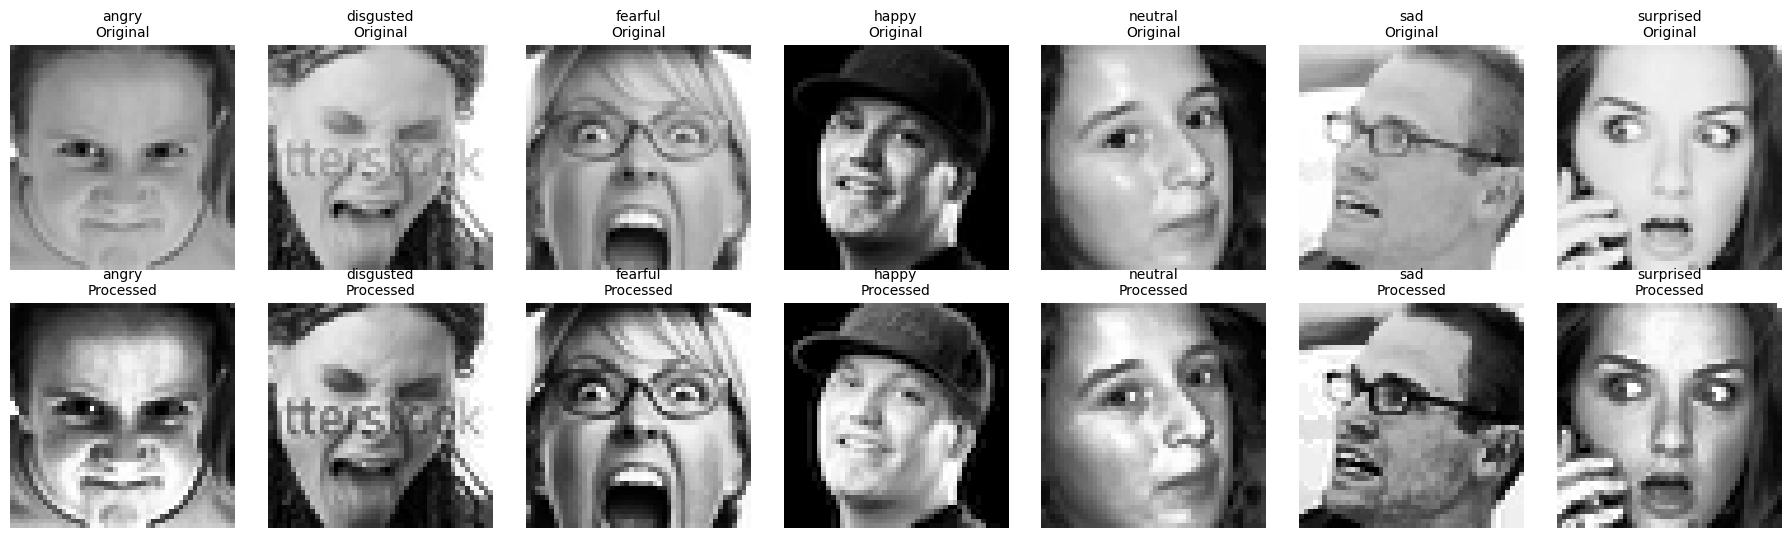

In [45]:
def preview_one_per_class(split="train"):
    split_dir = Path(DATA_ROOT) / split
    class_dirs = [d for d in sorted(split_dir.iterdir()) if d.is_dir()]
    if not class_dirs:
        raise ValueError(f"No class folders found in {split_dir}")

    # pick one random file per class
    valid_exts = {".png", ".jpg", ".jpeg", ".bmp"}
    samples = []
    for cdir in class_dirs:
        files = [p for p in cdir.glob("*") if p.suffix.lower() in valid_exts]
        if not files:
            continue
        samples.append((cdir.name, random.choice(files)))

    if not samples:
        raise ValueError("No images found to preview.")

    n = len(samples)
    plt.figure(figsize=(n*2.6, 5.4))

    # top row: originals
    for i, (cls, f) in enumerate(samples):
        img = imread_any(f, cv2.IMREAD_UNCHANGED)
        if img is None:
            continue
        if img.ndim == 3:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            gray = img
        gray = cv2.resize(gray, (48,48), interpolation=cv2.INTER_AREA)
        ax = plt.subplot(2, n, i+1)
        ax.imshow(gray, cmap='gray')
        ax.set_title(f"{cls}\nOriginal", fontsize=10)
        ax.axis('off')

    # bottom row: processed
    for i, (cls, f) in enumerate(samples):
        img = imread_any(f, cv2.IMREAD_UNCHANGED)
        if img is None:
            continue
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        proc = preprocess_emotion_48x48(img, size=(48,48), denoise=False)
        ax = plt.subplot(2, n, n+i+1)
        ax.imshow(proc, cmap='gray')
        ax.set_title(f"{cls}\nProcessed", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print("▶ Previewing one random sample per class from TRAIN (no files saved):")
preview_one_per_class(split="train")

In [50]:
from collections import Counter
import os
for split in ["train","test"]:
    counts = {cls: len(os.listdir(os.path.join(DATA_ROOT, split, cls)))
              for cls in os.listdir(os.path.join(DATA_ROOT, split)) if os.path.isdir(os.path.join(DATA_ROOT, split, cls))}
    print(split, counts)

train {'fearful': 4097, 'sad': 4830, 'angry': 3995, 'surprised': 3171, 'happy': 7215, 'disgusted': 436, 'neutral': 4965}
test {'neutral': 1233, 'sad': 1247, 'surprised': 831, 'fearful': 1024, 'happy': 1774, 'angry': 958, 'disgusted': 111}


In [51]:
PROCEED = True   # <<< CHANGE TO True WHEN YOU ARE HAPPY WITH THE PREVIEW
IMG_SIZE = (48,48)
DENOISE  = False  # set True if your images look noisy after preview

if PROCEED:
    # start fresh
    if os.path.exists(OUT_ROOT):
        shutil.rmtree(OUT_ROOT)
    Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)

    splits = ["train", "test"]
    valid_exts = {".png", ".jpg", ".jpeg", ".bmp"}

    for split in splits:
        in_split  = Path(DATA_ROOT) / split
        out_split = Path(OUT_ROOT)  / split

        class_dirs = sorted([p for p in in_split.iterdir() if p.is_dir()])
        print(f"\nProcessing split: {split}  (classes: {len(class_dirs)})")
        for cdir in class_dirs:
            files = [p for p in cdir.rglob("*") if p.suffix.lower() in valid_exts]
            print(f"  - {cdir.name}: {len(files)} images")
            for f in tqdm(files):
                try:
                    img = imread_any(f, cv2.IMREAD_UNCHANGED)
                    if img is None:
                        continue
                    if img.ndim == 2:
                        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

                    proc = preprocess_emotion_48x48(img, size=IMG_SIZE, denoise=DENOISE)

                    rel = f.relative_to(in_split)  # class/filename
                    out_path = (out_split / rel).with_suffix(".png")
                    save_png(proc, out_path)
                except Exception as e:
                    print(f"[skip] {f}: {e}")

    print("\n✅ Saved preprocessed dataset to:", OUT_ROOT)
else:
    print("\nℹ️ PROCEED is False — nothing saved. If you like the preview, set PROCEED=True and re-run this cell.")


Processing split: train  (classes: 7)
  - angry: 3995 images


100%|██████████| 3995/3995 [03:02<00:00, 21.92it/s]


  - disgusted: 436 images


100%|██████████| 436/436 [00:10<00:00, 41.52it/s]


  - fearful: 4097 images


...

  - sad: 1247 images


100%|██████████| 1247/1247 [00:54<00:00, 23.04it/s]


  - surprised: 831 images


100%|██████████| 831/831 [00:43<00:00, 18.93it/s]


✅ Saved preprocessed dataset to: /content/drive/MyDrive/Colab Notebooks/emotion_preprocessed
